Below, we will go through a simple example of how to use the code associated with this work. For this example, we will only consider the APOGEE SNC stars from DR19. The SDSS-V data needed from this tutorial can be downloaded directly from the SAS (<https://data.sdss.org/sas/dr19/spectro/astra/0.6.0/summary/astraAllStarASPCAP-0.6.0.fits.gz>). Below we show how to open the resulting file with the APOGEE data, filter on SNC targets and save the resulting data for later.

In [1]:
from astropy.table import Table, unique
from sdss_semaphore.targeting import TargetingFlags

# open the DR19 file with the APOGEE data
# download from: https://data.sdss.org/sas/dr19/spectro/astra/0.6.0/summary/astraAllStarASPCAP-0.6.0.fits.gz
dr19 = Table.read('../../../DR19/astraAllStarASPCAP-0.6.0.fits', hdu=2)

# use semaphore to identify stars in the SNC carton
flags = TargetingFlags(dr19['sdss5_target_flags'])
snc = flags.in_carton_name('mwm_snc_100pc')

# save the data
snc_100pc = unique(dr19[snc & (dr19['plx'] > 0)],
                   keys='gaia_dr3_source_id',
                   keep='first')
snc_100pc.rename_column('gaia_dr3_source_id', 'source_id')
snc_100pc[['source_id', 'ra', 'dec', 'fe_h', 'e_fe_h']].write('appendix_example.csv',
                                                              format='csv',
                                                              overwrite=True)


This saved file will serve as the basis of the observed data for our code. It is important to note that the GCNS was run with eDR3 data, so it is important that the required columns for the selection function match eDR3. The code automatically matches these for you based on the Gaia `source_id`. It will replace columns already present in the above file, like `ra`, if they exist though.

With the above file save, we can now run our selection function code! 
First, we need to calculate the selection function for this subset of 
100 pc objects. As a reminder, this is based on all of the SNC data considered, which is the DR19
 100 pc sample with an APOGEE spectrum. Below we show how the object is 
initialized. When initialized, it will automatically calculate the 
selection function. Additionally, if this is the first time running the 
code, it will automatically download the necessary GCNS data files.

In [2]:
# load all needed packages and functions
from snc_sf.selection_function import SNCSelectionFunction

import numpy as np
import polars as pl
import matplotlib.pylab as plt
from matplotlib.colors import LogNorm
import jax
jax.config.update("jax_enable_x64", False)

# below we configure the binning for the HR diagram for the subpopulation
# and the selection function, respectively
MG_bin_list = [0, 20, 0.25]  # [min, max, delta]

sf_bins={'healpix': 3,                   # order
         'phot_g_mean_mag': [0, 22, 1],  # [min, max, delta]
         'g_rp': [-0.4, 2.2, 0.05]}      # [min, max, delta]

# name of the file with the query result from above
data_file = 'appendix_example.csv'

# initilize the object
mean = False
sf = SNCSelectionFunction(data_file, sf_bins, MG_bin_list, mean=mean)


In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


/Users/imedan/Desktop/VU_PostDoc_Research/SDSS_V/selection_function/snc_sf/src/snc_sf/selection_function.py:183: UserWarning: Replacing user supplied ra column with data from GCNS.
  warnings.warn(f"Replacing user supplied {nc} column with data from GCNS.")
/Users/imedan/Desktop/VU_PostDoc_Research/SDSS_V/selection_function/snc_sf/src/snc_sf/selection_function.py:183: UserWarning: Replacing user supplied dec column with data from GCNS.
  warnings.warn(f"Replacing user supplied {nc} column with data from GCNS.")


Now the above objects includes the selection function! Within our object, we have two [Polars](https://pola.rs) dataframes; one for the GCNS and one for the data. These are accessed via `sf.gcns` and `sf.data`, respectively. To access the dataframe with the $k$ and $n$ values for each bin in the selection function, this can be found in the attribute `sf.subsamp`. These $k$ and $n$ values are also joined to the GCNS and DR19 data within their respective dataframes.

Next, we will select our subpopulation to then get the subpopulation probabilities. For this example, our subpopulation will stars observed with the SNC with $[Fe/H] > -0.5$, The below code shows how to filter the subpopulation and then run the MCMC to sample the posteriors of the subpopulation probabilities, $p_{\mathsf{sub}, k}$.

In [3]:
# initiallly calculate effective selection factor to get binning for GCNS
sf.evalutate_Ajk(weight_volume=False)

# filter dataset for metal-rich stars
filter_data = sf.data.filter(pl.col('fe_h') > -0.5)

# run the MCMC and get the subpopulation probability samples
p_samples, ev_valid = sf.forward_model(filter_data,
                                       num_warmup=1000,
                                       num_samples=2000,
                                       num_chains=1)


Running with beta_param = 2


sample: 100%|████████| 3000/3000 [09:01<00:00,  5.54it/s, 31 steps of size 1.57e-01. acc. prob=0.85]


Finally, we show a few examples on how to use these results to plot the subpopulation in the GCNS.
 First, we will show how to plot the 50th percentile of the samples of 
the subpopulation probabilities across the HR diagram:

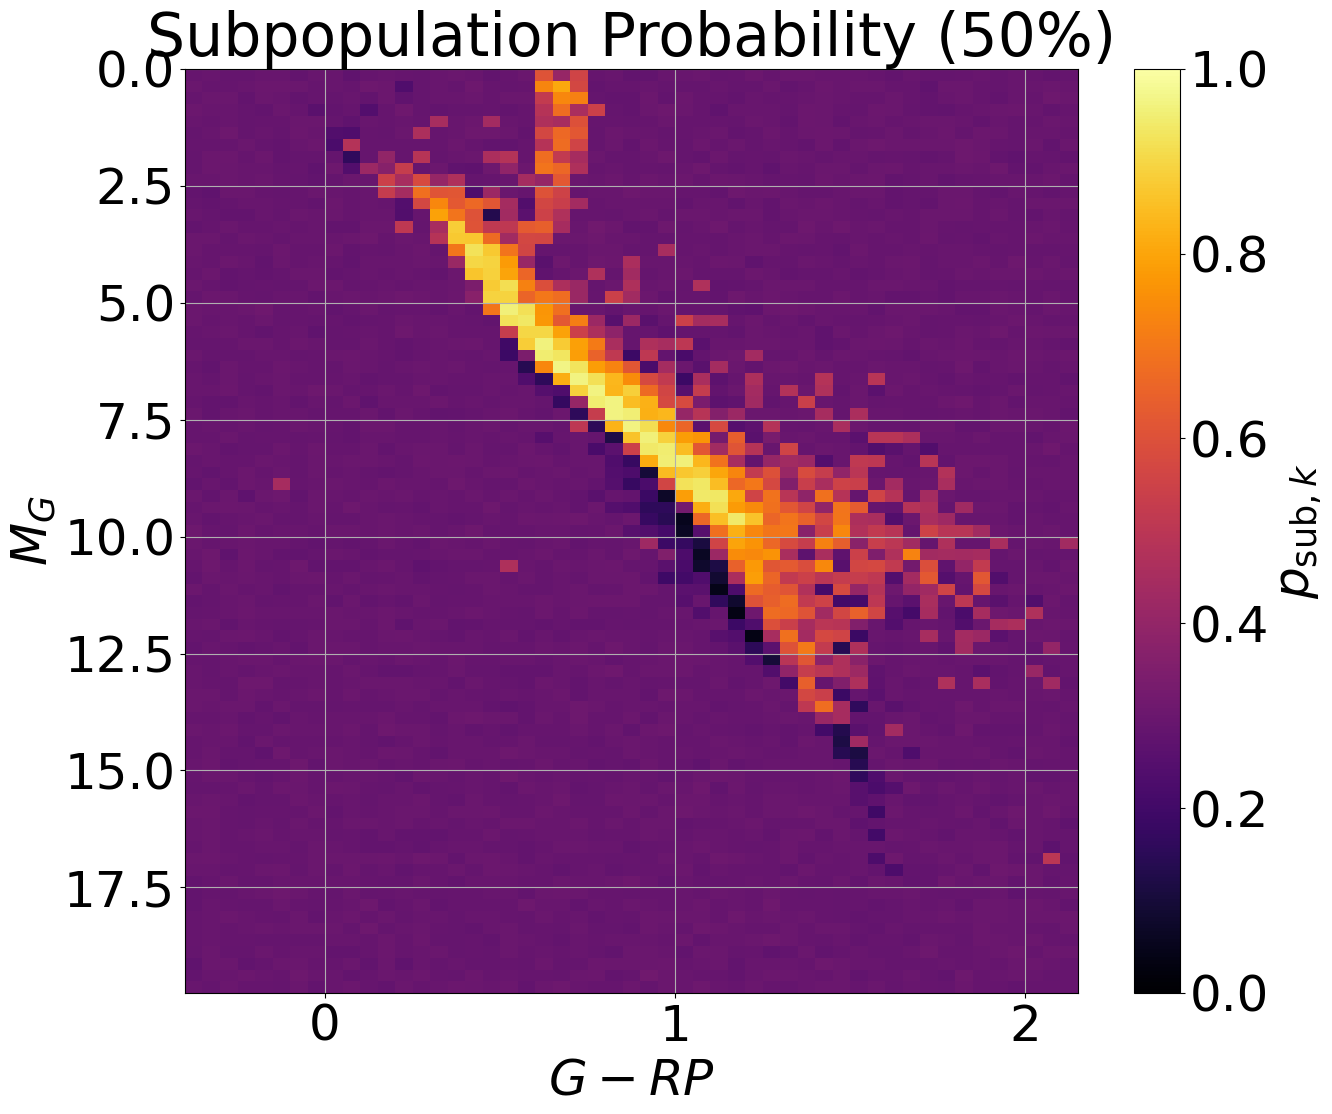

In [4]:
# have the bins for plotting
g_rp_bins = np.arange(*sf.sf_bins['g_rp'])
MG_bins = np.arange(*MG_bin_list)

# numbers in bin for reshaping the flattened p_samples
n_g_rp = len(g_rp_bins) - 1
n_mg = len(MG_bins) - 1

# get the 50th percentile of the samples in 2D array
p_50perc = np.nanpercentile(p_samples.reshape((-1, n_g_rp, n_mg)), 50, axis=0)

# plot the results
f, ax1 = plt.subplots(1, 1, figsize=(12 * 1.2, 10 * 1.2))
dens = ax1.imshow(p_50perc.T,
                  origin='lower', aspect='auto',
                  extent=(g_rp_bins.min(), g_rp_bins.max(), MG_bins.min(), MG_bins.max()),
                  vmin=0, vmax=1, cmap='inferno')
ax1.set_xlabel(r'$G-RP$')
ax1.set_ylabel(r'$M_G$')
ax1.invert_yaxis()
ax1.grid()
ax1.set_title('Subpopulation Probability (50%)')
plt.colorbar(dens, ax=ax1, label=r'$p_{\mathsf{sub}, k}$')
plt.savefig('paper_plots/appendix_ex/subpop_prob.png', bbox_inches='tight')
plt.show()


We can also plot the 50th percentile of the counts across the HR diagram for this subpopulation:

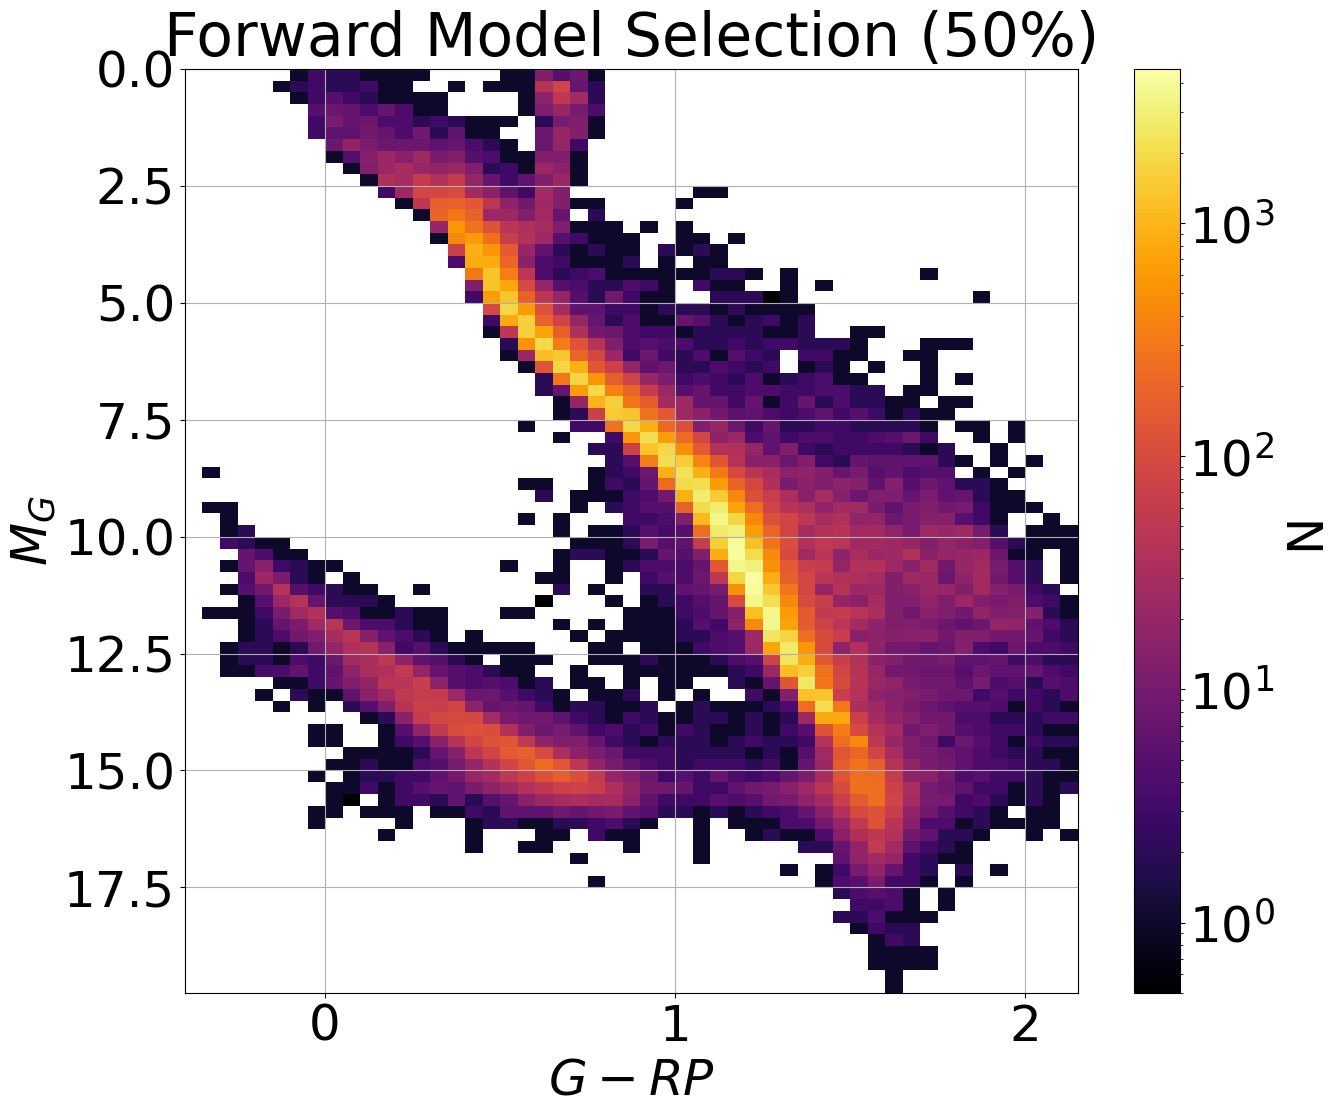

In [5]:
# random seed to reproduce results
RNG = np.random.default_rng(666)

# get the total number of stars in the GCNS across the HR diagram
gcns_filter = sf.gcns.filter(pl.Series(sf.gcns_valid))
Ntot, _, _ = np.histogram2d(gcns_filter['g_rp'].to_numpy(), gcns_filter['MG'].to_numpy(),
                            bins=[g_rp_bins, MG_bins])

# based on p_samples, draw number in subpopulation
Nsub = RNG.binomial(Ntot.astype(int), p_samples.reshape((-1, n_g_rp, n_mg)))

# get 50th percentile
Nsub_50perc = np.nanpercentile(Nsub, 50, axis=0)

# plot the results
f, ax1 = plt.subplots(1, 1, figsize=(12 * 1.2, 10 * 1.2))
dens = ax1.imshow(Nsub_50perc.T,
                  origin='lower', aspect='auto',
                  extent=(g_rp_bins.min(), g_rp_bins.max(), MG_bins.min(), MG_bins.max()),
                  norm=LogNorm(), cmap='inferno')
ax1.set_xlabel(r'$G-RP$')
ax1.set_ylabel(r'$M_G$')
ax1.invert_yaxis()
ax1.grid()
ax1.set_title('Forward Model Selection (50%)')
plt.colorbar(dens, ax=ax1, label='N')
plt.savefig('paper_plots/appendix_ex/subpop_select.png', bbox_inches='tight')
plt.show()


Finally, the code provides ways to flag subpopulation probability posteriors that are the same as the prior assumption. Below we show how to output these flags and identify the "bad" regions across the HR diagram.

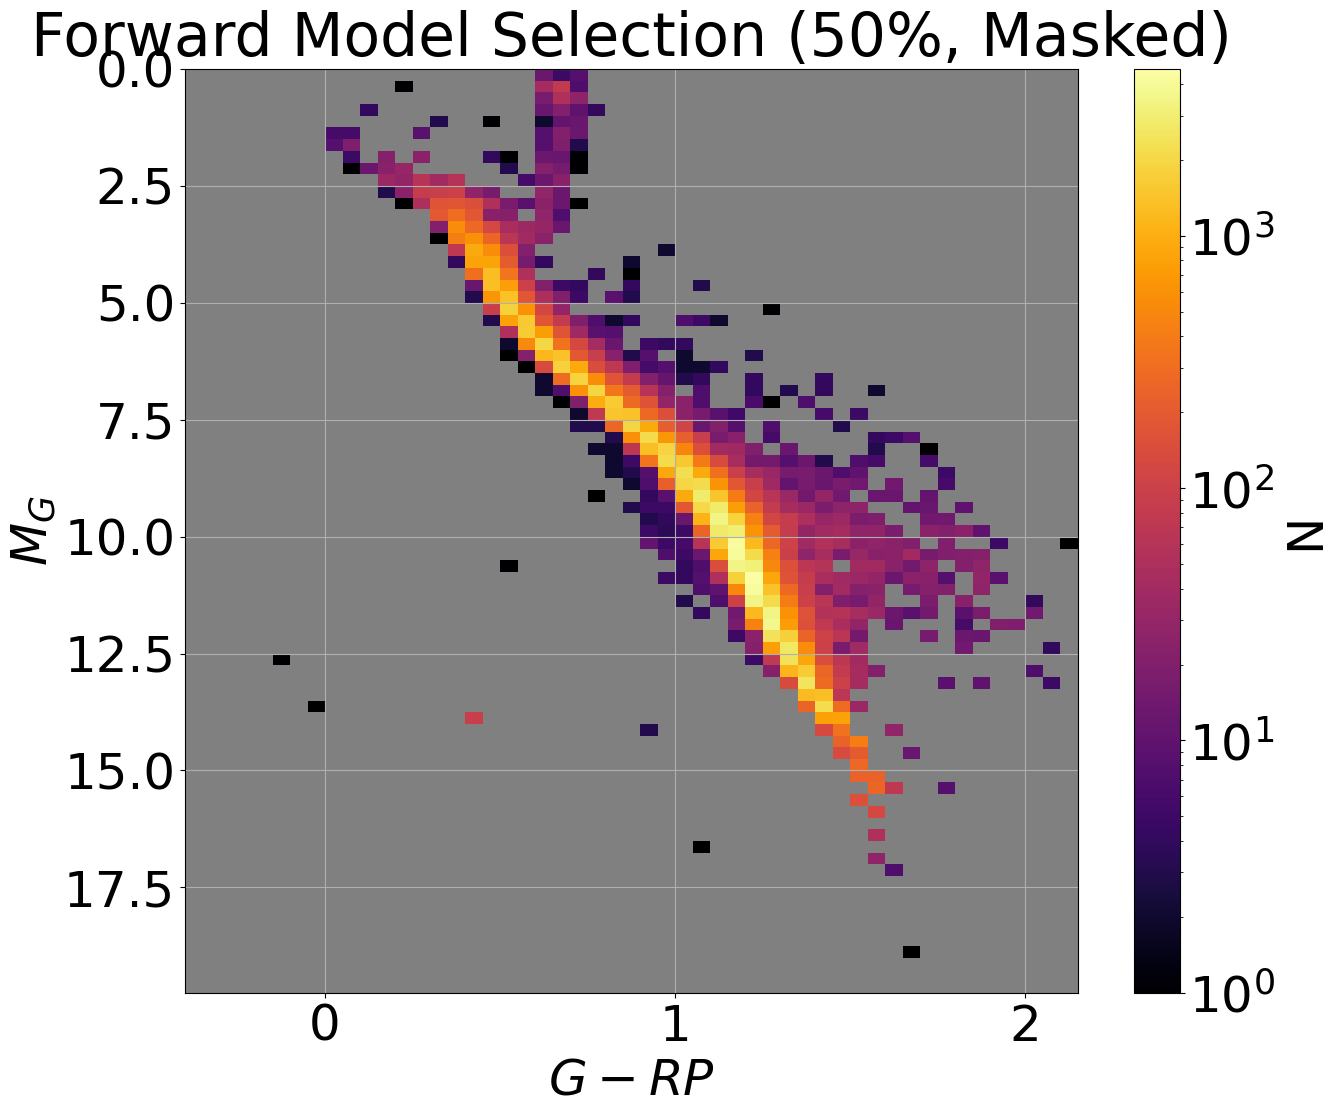

In [6]:
dist_change, kl_vals, kl_mean, kl_std, sample_mean, sample_var, prior_mean, prior_var = sf.check_posterior_samples(
    filter_data, p_samples)


# mask out regions returning the prior
Nsub_50perc[~dist_change.reshape((n_g_rp, n_mg))] = np.nan

# plot the results
f, ax1 = plt.subplots(1, 1, figsize=(12 * 1.2, 10 * 1.2))

# colormap to grey out nan regions
cmap = plt.cm.inferno.copy()
cmap.set_bad('grey')

dens = ax1.imshow(Nsub_50perc.T,
                  origin='lower', aspect='auto',
                  extent=(g_rp_bins.min(), g_rp_bins.max(), MG_bins.min(), MG_bins.max()),
                  norm=LogNorm(), cmap=cmap)
ax1.set_xlabel(r'$G-RP$')
ax1.set_ylabel(r'$M_G$')
ax1.invert_yaxis()
ax1.grid()
ax1.set_title('Forward Model Selection (50%, Masked)')
plt.colorbar(dens, ax=ax1, label='N')
plt.savefig('paper_plots/appendix_ex/subpop_select_masked.png', bbox_inches='tight')
plt.show()


These plots demonstrate that the model correctly identifies more 
metal-rich stars as being redder on the HR diagram. As a note, these 
plots only show the 50th percentile. With the variable `p_samples`,
 you have access to the full posterior of the subpopulation probability.
 Similar to the results in the main paper, with this you will find that 
under-sampled regions are less constrained and will typically return the
 prior for the subpopulation probability, as indicated by the masked, grey regions. For example, this occurs for the entire white dwarf sequence in this instance.